### Mirror Randomised Benchmarking (MRB): Custom Noisy Backend Simulation

This section imports the required libraries, creates a fully connected quantum device, and defines a custom noisy backend for simulation. The number of qubits (currently 8) and the noise levels can be changed to simulate different quantum devices. The resulting backend is used to run the Mirror Randomized Benchmarking (MRB) experiments.


In [ ]:
import matplotlib.pyplot as plt

from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
from qiskit_device_benchmarking.bench_code.mrb.mirror_rb_analysis import MirrorRBAnalysis
from qiskit_device_benchmarking.bench_code.mrb import MirrorRB
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler.coupling import CouplingMap

# Define a full coupling map for n qubits (fully connected for simplicity)

edges = [(i, j) for i in range(6) for j in range(6) if i != j]

coupling_map = CouplingMap(edges)

# custom noisy backend (or an attempt at one, at least)
class NoisyBackend(GenericBackendV2):
    def __init__(
        self,
        num_qubits: int,
        basis_gates: list[str] | None = None,
        coupling_map: list[list[int]] = [],
        p1: float = 0,
        p2: float = 0,
    ):
        self.p = (p1,p2)
        super().__init__(
            num_qubits,
            basis_gates,
            coupling_map=coupling_map,
            noise_info = (p1>0 or p2 >0)
            )
    def _get_noise_defaults(self, name: str, num_qubits: int) -> tuple:
        if name in ['delay', 'reset']:
            return (self.p[0],self.p[0])
        else:
            if num_qubits == 1:
                return (0,0,self.p[0],self.p[0])
            else:
                return (0,0,self.p[1],self.p[1])
            
p = 1e-2

backend = NoisyBackend(
    num_qubits=8,
    basis_gates=["id", "h", "x", "y", "z", "s", "cx"],
    p1=p/10,
    p2=p,
    coupling_map=[list(edge) for edge in coupling_map.get_edges()]
)

 ### Configure and Run the MRB Experiment
 This section sets the **configurable runtime parameters** for the Mirror Randomized Benchmarking experiment, such as the number of shots, circuit lengths, qubits, and random samples. These values can be adjusted to change the experiment without modifying the benchmark code. The experiment is then executed, and the results are stored in `rb_data`.


In [7]:
# number of shots per circuit
shots = 100

# lengths of different mirror circuits to run
lengths = [2]+[4,10,20,50,100]

# upper bound the qubit number or sherbrooke doesn't work
num_qubits = 3

# set up the experiment object
exp = MirrorRB(
    range(num_qubits),
    lengths,
    backend=backend,
    two_qubit_gate_density=0.25,
    num_samples=20,
    )
exp.set_run_options(
    shots=shots
)
#run
rb_data = exp.run()
print(rb_data.job_ids)

['b08bdfe6-9d81-40ef-9d5c-5945c474d0a7']


### Analyze and Visualize the Results

This section analyzes the benchmark data using the Effective Polarization metric and generates a plot of the results. The analysis metric can be changed by modifying the analyzed_quantity option to evaluate different aspects of the benchmark performance.

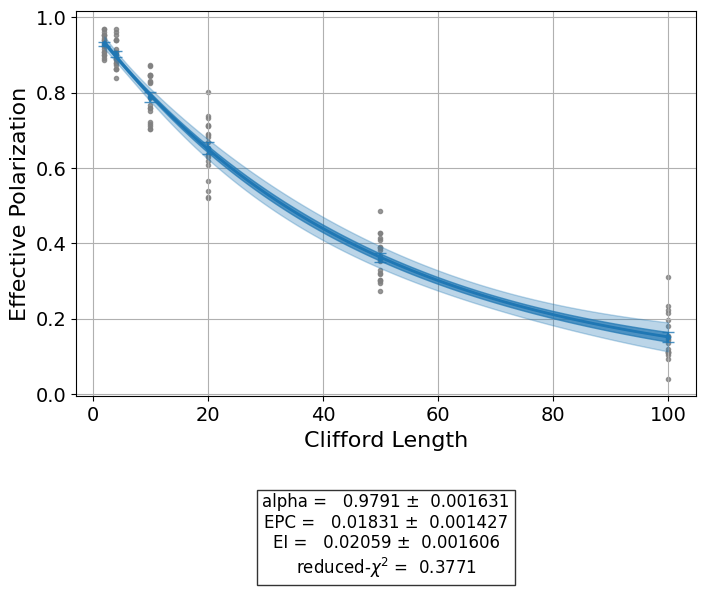

In [4]:
from qiskit_device_benchmarking.bench_code.mrb.mirror_rb_analysis import MirrorRBAnalysis

analysis_obj = MirrorRBAnalysis()
analysis_obj.set_options(analyzed_quantity='Effective Polarization')
analysis = analysis_obj.run(rb_data)
analysis.block_for_results()
analysis.figure(0)